In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
df = pd.read_csv('pandas/data/flight.csv')
df.head(3)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956


In [7]:
df = df.drop('Unnamed: 0', axis=1)
df.head(3)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [10]:
# 범주형 컬럼의 고유값 수 (고카디널리티 확인)
obj_cols = df.select_dtypes('object').columns
df[obj_cols].nunique().sort_values(ascending=False)

flight              1561
airline                6
source_city            6
departure_time         6
arrival_time           6
destination_city       6
stops                  3
class                  2
dtype: int64

In [11]:
df = df.drop('flight', axis=1)
df.head(3)

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956


In [13]:
df_copy = pd.get_dummies(df, drop_first=True, dtype=int)
df_copy.head(3)

,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,source_city_Delhi,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,2.17,1,5953,0,0,0,1,0,0,1,...,0,0,0,1,0,0,0,0,1,1
1,2.33,1,5953,0,0,0,1,0,0,1,...,0,0,1,0,0,0,0,0,1,1
2,2.17,1,5956,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,1


In [16]:
target_col = 'price'
X = df_copy.drop(target_col, axis=1)
y = df_copy[target_col]

print(X.shape, y.shape)


(300153, 30) (300153,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression


lr = LinearRegression()
model = lr.fit(X_train, y_train)

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

y_pred = model.predict(X_test)

print(f'MAE  = {mean_absolute_error(y_test, y_pred):,.2f}')
print(f'RMSE1 = {np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}')
print(f'RMSE2 = {root_mean_squared_error(y_test, y_pred):,.2f}')
print(f'R^2  = {r2_score(y_test, y_pred):.4f}')

MAE  = 4,553.29
RMSE1 = 6,761.71
RMSE2 = 6,761.71
R^2  = 0.9113


In [26]:
coef = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print('가격 영향력 Top 10:')
coef_10 = coef.head(10)

가격 영향력 Top 10:


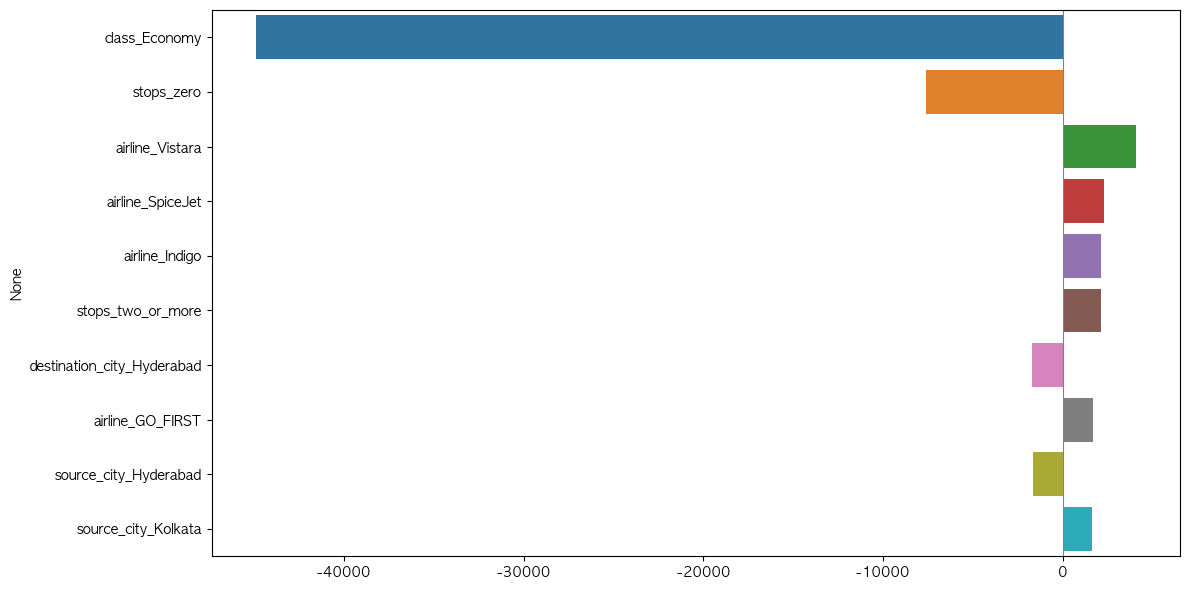

In [32]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x=coef_10.values,
    y=coef_10.index,
    hue=coef_10.index,   # ← y와 동일하게 추가
    legend=False,        # ← 막대마다 색이 달라 범례 불필요    
)
plt.axvline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()